Diffusers and pipeline Code

In [1]:
from diffusers import StableDiffusion3Pipeline
import torch
from config import LAM_VALUES, TSR_DIR, PT_TSR_DIR, PROMPTS_FILE, MODEL_CACHE, SEED, TSR_SIGMA, SWAP_ALGORITHM, N_INF_STEPS, GUIDANCE_SCALE

    # ── Load model once ───────────────────────────────────────────────────────────
pipe = StableDiffusion3Pipeline.from_pretrained(
	"stabilityai/stable-diffusion-3-medium-diffusers",
	torch_dtype=torch.float16,
	cache_dir=MODEL_CACHE,
)
pipe = pipe.to("cuda")
pipe.set_progress_bar_config(disable=True)

Loading pipeline components...:   0%|          | 0/9 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Imports, configs

In [2]:
from pathlib import Path
import gc
import pandas as pd
from tqdm import tqdm
import shutil

TSR_DIR     = Path("/n/netscratch/kempner_undergrads/Everyone/zwu/parallel_toy/images/new_tsr_samples_tester")
PT_TSR_DIR  = Path("/n/netscratch/kempner_undergrads/Everyone/zwu/parallel_toy/images/new_pt_samples_tester")

REPLICA_EXCHANGE = True
LAM_VALUES = [1.15]
INDEX_UNTIL = 3

gc.collect()
torch.cuda.empty_cache()
    

In [3]:
if PT_TSR_DIR.exists():
    shutil.rmtree(PT_TSR_DIR)


Sample!

In [4]:
# ── Load prompts once ─────────────────────────────────────────────────────────
prompts = pd.read_csv(PROMPTS_FILE, usecols=["text"], nrows=INDEX_UNTIL)["text"].tolist()
print(f"Loaded {len(prompts)} prompts")


replica_exchanges = [True, False]

lam_dirs = {}
for re in replica_exchanges:
	base = PT_TSR_DIR if re else TSR_DIR
	lam_dirs[re] = {l: base / f"lam{l:.3f}".replace(".", "p") for l in LAM_VALUES}
	for d in lam_dirs[re].values():
		d.mkdir(parents=True, exist_ok=True)

# ── Sweep ─────────────────────────────────────────────────────────────────────
for idx, prompt in enumerate(prompts):
	
	for replica_exchange in replica_exchanges:
	
		for tsr_lam in tqdm(LAM_VALUES, desc=f"idx={idx} re={replica_exchange}"):

			output_dir = lam_dirs[replica_exchange][tsr_lam]

			if (output_dir / f"{idx:05d}.png").exists():
				continue

			generator = torch.Generator(device="cuda").manual_seed(SEED)

			images = pipe(
				prompt,
				negative_prompt="",
				num_inference_steps=N_INF_STEPS,
				guidance_scale=GUIDANCE_SCALE,
				tsr_lam=tsr_lam,
				tsr_sigma=TSR_SIGMA,
				replica_exchange=replica_exchange,
				swap_algorithm=SWAP_ALGORITHM,
				generator=generator,
			).images

			out_path = output_dir / f"{idx:05d}.png"
			images[0].save(out_path, icc_profile=None)


			del images
		torch.cuda.empty_cache()

print("\n All k values complete.")

Loaded 3 prompts


idx=0 re=True:   0%|          | 0/1 [00:00<?, ?it/s]

 We tsr by 1.15 with replica exchange True
 f between 1.150390625 and 1.0458984375 mean 0.0
 energy diff 0.0 between lams s 1.0458984375 and t 1.150390625 temp s 1.0 t 1.0
Time 1000.00 swap btwn source 1.05 and target 1.15 accept 1.000 std 0.984
 f between 1.150390625 and 1.3916015625 mean 4.768039070768282e-05
 energy diff -0.0003045797348022461 between lams s 1.3916015625 and t 1.150390625 temp s 0.999505341053009 t 0.9998099207878113
Time 988.27 swap btwn source 1.39 and target 1.15 accept 1.000 std 0.972
 f between 1.150390625 and 1.0458984375 mean -4.018785693915561e-05
 energy diff 0.0005614161491394043 between lams s 1.0458984375 and t 1.150390625 temp s 0.9997531771659851 t 0.9991917610168457
Time 975.98 swap btwn source 1.05 and target 1.15 accept 1.000 std 0.959
 f between 1.150390625 and 1.3916015625 mean 0.00025790309882722795
 energy diff -0.00315934419631958 between lams s 1.3916015625 and t 1.150390625 temp s 0.9948607683181763 t 0.9980201125144958
Time 963.08 swap btwn 

idx=1 re=True:   0%|          | 0/1 [00:00<?, ?it/s]

 We tsr by 1.15 with replica exchange True
 f between 1.150390625 and 1.0458984375 mean 0.0
 energy diff 0.0 between lams s 1.0458984375 and t 1.150390625 temp s 1.0 t 1.0
Time 1000.00 swap btwn source 1.05 and target 1.15 accept 1.000 std 0.985
 f between 1.150390625 and 1.3916015625 mean 3.0569382943212986e-05
 energy diff -0.0003045797348022461 between lams s 1.3916015625 and t 1.150390625 temp s 0.999505341053009 t 0.9998099207878113
Time 988.27 swap btwn source 1.39 and target 1.15 accept 1.000 std 0.972
 f between 1.150390625 and 1.0458984375 mean -4.1710969526320696e-05
 energy diff 0.0005614161491394043 between lams s 1.0458984375 and t 1.150390625 temp s 0.9997531771659851 t 0.9991917610168457
Time 975.98 swap btwn source 1.05 and target 1.15 accept 1.000 std 0.959
 f between 1.150390625 and 1.3916015625 mean 0.00018091866513714194
 energy diff -0.00315934419631958 between lams s 1.3916015625 and t 1.150390625 temp s 0.9948607683181763 t 0.9980201125144958
Time 963.08 swap btw

idx=2 re=True:   0%|          | 0/1 [00:00<?, ?it/s]

 We tsr by 1.15 with replica exchange True
 f between 1.150390625 and 1.0458984375 mean 0.0
 energy diff 0.0 between lams s 1.0458984375 and t 1.150390625 temp s 1.0 t 1.0
Time 1000.00 swap btwn source 1.05 and target 1.15 accept 1.000 std 0.985
 f between 1.150390625 and 1.3916015625 mean 1.6983814930426888e-05
 energy diff -0.0003045797348022461 between lams s 1.3916015625 and t 1.150390625 temp s 0.999505341053009 t 0.9998099207878113
Time 988.27 swap btwn source 1.39 and target 1.15 accept 1.000 std 0.973
 f between 1.150390625 and 1.0458984375 mean -2.9669552532141097e-05
 energy diff 0.0005614161491394043 between lams s 1.0458984375 and t 1.150390625 temp s 0.9997531771659851 t 0.9991917610168457
Time 975.98 swap btwn source 1.05 and target 1.15 accept 1.000 std 0.961
 f between 1.150390625 and 1.3916015625 mean 0.00012526640784926713
 energy diff -0.00315934419631958 between lams s 1.3916015625 and t 1.150390625 temp s 0.9948607683181763 t 0.9980201125144958
Time 963.08 swap btw

idx=2 re=False: 100%|██████████| 1/1 [00:00<00:00, 1684.46it/s]


 All k values complete.


Fid computation

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

/n/home00/zoewu/.local/lib/python3.12/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Computing real image features...


100%|██████████| 1/1 [00:00<00:00,  1.34it/s]


Real features computed from 3 images.


── lam1p150 ──


CLIP lam=1.15: 100%|██████████| 3/3 [00:00<00:00, 18.93it/s]


[True]  lam=1.150  FID=246.2223  CLIP=31.1180


CLIP lam=1.15: 100%|██████████| 3/3 [00:00<00:00, 20.64it/s]


[False]  lam=1.150  FID=262.7582  CLIP=31.1592


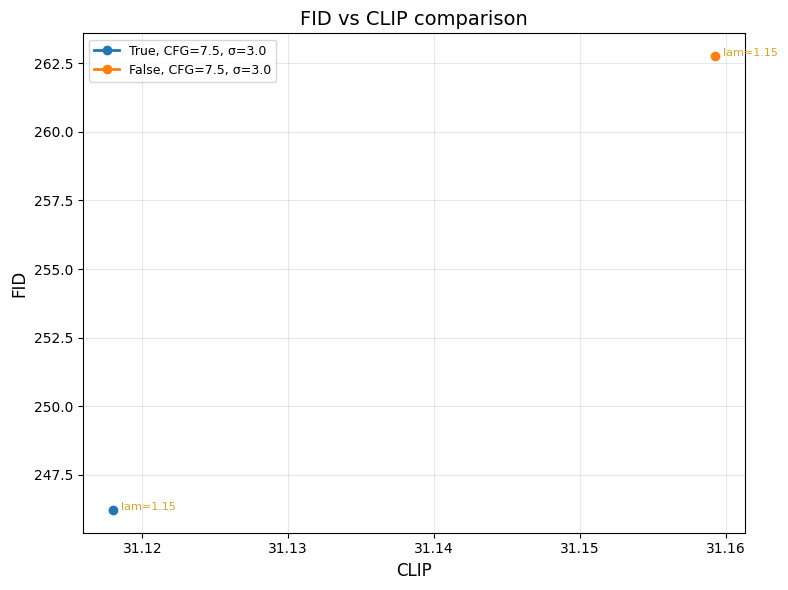

{True: {1.15: (np.float64(246.22231337350786),
   np.float64(31.117984771728516))},
 False: {1.15: (np.float64(262.75824283964687),
   np.float64(31.159245173136394))}}

In [5]:
from fid import compute_sweep
# from config import LAM_VALUES, TSR_DIR, PT_TSR_DIR, PROMPTS_FILE, MODEL_CACHE, SEED, TSR_SIGMA, SWAP_ALGORITHM, N_INF_STEPS, GUIDANCE_SCALE


compute_sweep(
	lam_values=LAM_VALUES,
	replica_exchanges=[True, False],
	device="cuda",
	target_indices=None,
	index_until = INDEX_UNTIL,
	pt_sr_dir = PT_TSR_DIR,
	tsr_dir = TSR_DIR,
)